In [ ]:
from google.colab import files
uploaded = files.upload()


Saving datos.csv to datos.csv


Saving datos.csv to datos (1).csv
Ejecutando regresiones con OLS...


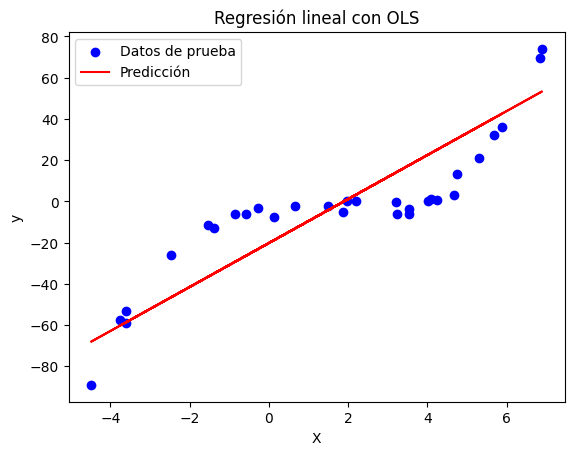

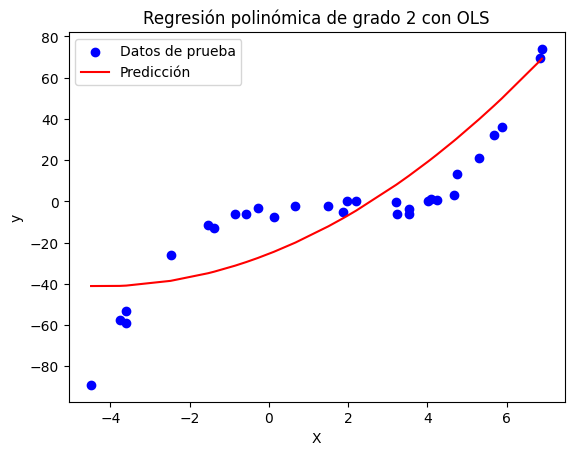

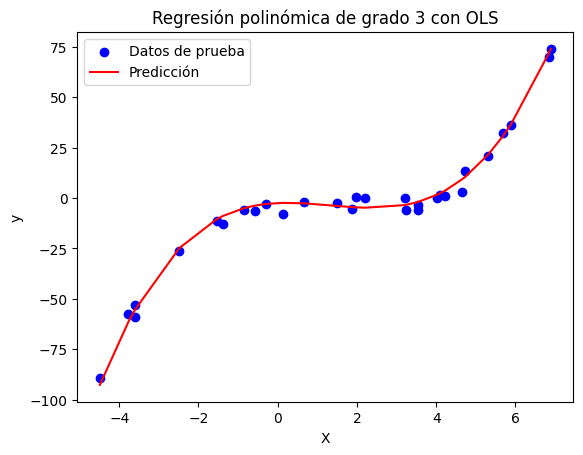

Ingresa el número de iteraciones para SGD: 10000
Ingresa la tasa de aprendizaje (alpha) para SGD: 0.0000001
Ejecutando regresiones con SGD...


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1616: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


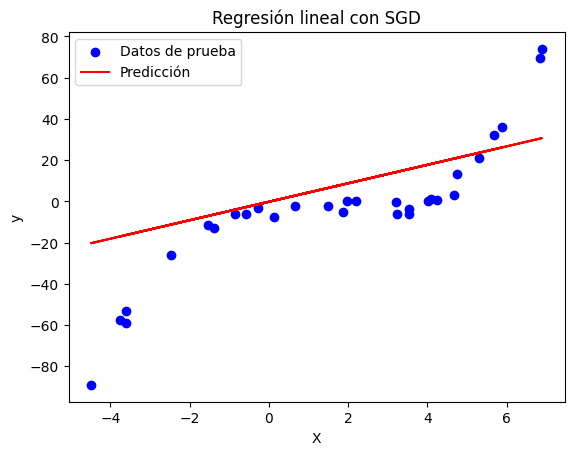

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1616: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


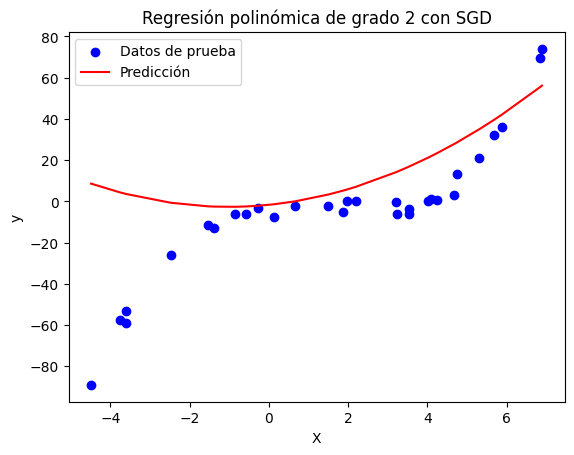

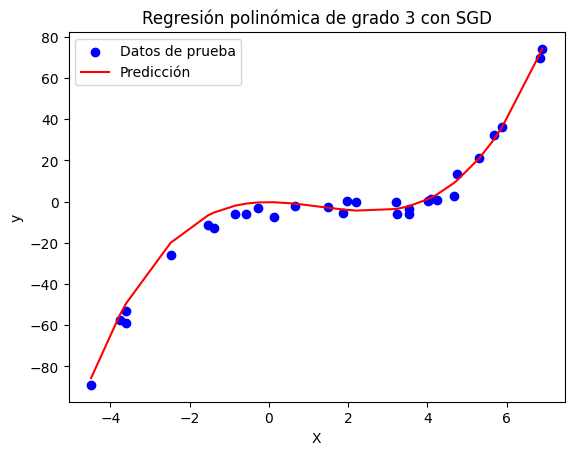


Resumen de resultados:
Modelo                                   MSE                  R2                  
Regresión lineal con OLS                 2.96095e+02          7.19805e-01         
Regresión polinómica de grado 2 con OLS  3.52437e+02          6.66487e-01         
Regresión polinómica de grado 3 con OLS  8.48785e+00          9.91968e-01         
Regresión lineal con SGD                 5.54963e+02          4.74837e-01         
Regresión polinómica de grado 2 con SGD  8.72425e+02          1.74421e-01         
Regresión polinómica de grado 3 con SGD  1.61071e+01          9.84758e-01         


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import operator

# Cargar el archivo CSV desde Google Colab
from google.colab import files
uploaded = files.upload()

# Cargar el conjunto de datos (el archivo CSV cargado debe estar en el mismo directorio)
datos = pd.read_csv('datos.csv')  # Ajusta el nombre del archivo si es necesario
X = datos.iloc[:, :-1].values  # Asume que todas las columnas excepto la última son características
y = datos.iloc[:, -1].values   # Asume que la última columna es el objetivo

# Dividir los datos
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=0)

# Función para graficar resultados
def graficar_resultados(X, y_real, y_pred, titulo):
    plt.scatter(X, y_real, color='blue', label='Datos de prueba')
    plt.plot(X, y_pred, color='red', label='Predicción')
    plt.title(titulo)
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.show()

# Función para entrenar y evaluar un modelo de regresión
def evaluar_modelo(modelo, X_entrenamiento, X_prueba, y_entrenamiento, y_prueba, poly=None, titulo=""):
    # Entrenar el modelo
    if poly:
        X_entrenamiento_poly = poly.fit_transform(X_entrenamiento)
        X_prueba_poly = poly.transform(X_prueba)
        modelo.fit(X_entrenamiento_poly, y_entrenamiento)
        y_pred = modelo.predict(X_prueba_poly)
    else:
        modelo.fit(X_entrenamiento, y_entrenamiento)
        y_pred = modelo.predict(X_prueba)

    # Métricas de evaluación
    mse = mean_squared_error(y_prueba, y_pred)
    r2 = r2_score(y_prueba, y_pred)
    resultados.append((titulo, mse, r2))  # Almacenar resultados para el resumen

    # Ordenar para regresión polinomial (si es necesario para graficar)
    if poly:
        indices_ordenados = X_prueba[:, 0].argsort()
        graficar_resultados(X_prueba[indices_ordenados], y_prueba[indices_ordenados], y_pred[indices_ordenados], titulo)
    else:
        graficar_resultados(X_prueba, y_prueba, y_pred, titulo)

# Lista para almacenar los resultados
resultados = []

# Regresión de Mínimos Cuadrados Ordinarios (OLS) - Lineal y Polinómica
print("Ejecutando regresiones con OLS...")
evaluar_modelo(LinearRegression(), X_entrenamiento, X_prueba, y_entrenamiento, y_prueba, titulo="Regresión lineal con OLS")

for grado in [2, 3]:
    poly_features = PolynomialFeatures(degree=grado)
    evaluar_modelo(LinearRegression(), X_entrenamiento, X_prueba, y_entrenamiento, y_prueba, poly=poly_features, titulo=f"Regresión polinómica de grado {grado} con OLS")

# Solicitar parámetros para SGD al usuario
iteraciones = int(input("Ingresa el número de iteraciones para SGD: "))
alpha = float(input("Ingresa la tasa de aprendizaje (alpha) para SGD: "))

# Regresión con Descenso de Gradiente Estocástico (SGD) - Lineal y Polinómica
print("Ejecutando regresiones con SGD...")
evaluar_modelo(SGDRegressor(max_iter=iteraciones, eta0=alpha, tol=0.00112, learning_rate='constant'), X_entrenamiento, X_prueba, y_entrenamiento, y_prueba, titulo="Regresión lineal con SGD")

for grado in [2, 3]:
    poly_features = PolynomialFeatures(degree=grado)
    evaluar_modelo(SGDRegressor(max_iter=iteraciones, eta0=alpha, tol=0.00112, learning_rate='constant'), X_entrenamiento, X_prueba, y_entrenamiento, y_prueba, poly=poly_features, titulo=f"Regresión polinómica de grado {grado} con SGD")

# Resumen de todos los resultados
print("\nResumen de resultados:")
print(f"{'Modelo':<40} {'MSE':<20} {'R2':<20}")
for titulo, mse, r2 in resultados:
    print(f"{titulo:<40} {mse:<20.5e} {r2:<20.5e}")
